# Objectif 
 
Étude de sensibilité en profondeur. 

Date de création : 01/09/2026

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
import source.global_constants as g
import propa.kraken_toolbox.plot_utils as pu


from propa.kraken_toolbox.utils import default_nb_rcv_z
from publication.publication_figure import PubFigure, LargeFigure
from source.normal_modes import (
    pekeris_cutoff_frequency,
    pekeris_n_modes,
)
from misc import mult_along_axis, progression_bar

from illustration_rtf.src.utils import (
    baseline_env,
    baseline_sig,
    baseline_src_rcv,
    run_sensibility_study,
    calc_gamma_dist,
    calc_mainlobe_width_3dB,
    calc_monotonicity_domain, 
    run_single_sensibility_test,
)

from source.normal_modes import pekeris_green_fct
from time import time

pfig = PubFigure()

In [2]:
from propa.kraken_toolbox.src.kraken_env import (
    KrakenEnv,
    KrakenMedium,
    KrakenBottomHalfspace,
    KrakenField,
    KrakenFlp,
)
from propa.kraken_toolbox.src.kraken_manager import KrakenManager

In [3]:
folder_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration_rtf\src"
tc_root_dir = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\testcases"
)
img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")


# Chargement de l'environnement 

In [4]:
# Environment
env_param = baseline_env()
print("Baseline environement properties:")
for k in env_param.keys():
    print(f"\t{k} = {env_param[k]}")

# Signal
sig_param = baseline_sig()
print("Baseline signal properties:")
for k in sig_param.keys():
    print(f"\t{k} = {sig_param[k]}")

# Source receiver config
src_rcv_param = baseline_src_rcv()
print("Baseline src / rcv configuration:")
for k in src_rcv_param.keys():
    print(f"\t{k} = {src_rcv_param[k]}")

Baseline environement properties:
	c1 = 1500
	c2 = 1600
	rho1 = 1000.0
	rho2 = 1500.0
	attn2 = 0.2
	depth = 100
Baseline signal properties:
	freq = [  0.    0.2   0.4   0.6   0.8   1.    1.2   1.4   1.6   1.8   2.    2.2
   2.4   2.6   2.8   3.    3.2   3.4   3.6   3.8   4.    4.2   4.4   4.6
   4.8   5.    5.2   5.4   5.6   5.8   6.    6.2   6.4   6.6   6.8   7.
   7.2   7.4   7.6   7.8   8.    8.2   8.4   8.6   8.8   9.    9.2   9.4
   9.6   9.8  10.   10.2  10.4  10.6  10.8  11.   11.2  11.4  11.6  11.8
  12.   12.2  12.4  12.6  12.8  13.   13.2  13.4  13.6  13.8  14.   14.2
  14.4  14.6  14.8  15.   15.2  15.4  15.6  15.8  16.   16.2  16.4  16.6
  16.8  17.   17.2  17.4  17.6  17.8  18.   18.2  18.4  18.6  18.8  19.
  19.2  19.4  19.6  19.8  20.   20.2  20.4  20.6  20.8  21.   21.2  21.4
  21.6  21.8  22.   22.2  22.4  22.6  22.8  23.   23.2  23.4  23.6  23.8
  24.   24.2  24.4  24.6  24.8  25.   25.2  25.4  25.6  25.8  26.   26.2
  26.4  26.6  26.8  27.   27.2  27.4  27.6  27.8  2

In [5]:
# Signal
freq = sig_param.get("freq", None)
fs = sig_param.get("fs", None)
fmax = sig_param.get("fmax", None)
# Environment
d = env_param.get("depth", None)
c1 = env_param.get("c1", None)
c2 = env_param.get("c2", None)
rho1 = env_param.get("rho1", None)
rho2 = env_param.get("rho2", None)
attn2 = env_param.get("attn2", None)

# Source / receiver
z_s = src_rcv_param.get("z_s", 5)
z = src_rcv_param.get("z_rcv", 20)
r_grid = src_rcv_param.get("r_rcv", np.array([1e4]))
r0 = src_rcv_param.get("r0", 1e4)

# Convert r_grid to km
r_grid = r_grid * 1e-3

## Adaptation au code pour Kraken 

In [6]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration_rtf\data"
sensi_directory = os.path.join(root_data, "sensibility")
os.makedirs(sensi_directory, exist_ok=True)

In [7]:
env_filename = "sensibility_depth"
title = "Sensibility study (waveguide depth)"

In [16]:
# Keeps only frequencies above mode 1 cut-off
kraken_freq = freq[freq > pekeris_cutoff_frequency(m=1, c1=c1, c2=c2, d=d)]
# Use only propative modes
nb_modes = pekeris_n_modes(f=fmax, c1=c1, c2=c2, d=d)
clim_max = 2000

# ----------------------------------------------------------------------
# 1. Environment: Pekeris waveguide
# ----------------------------------------------------------------------
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=[0.0, d],
    c_p=[c1, c1],  # isovelocity water column
    rho=rho1,
)

bottom_hs = KrakenBottomHalfspace(
    halfspace_properties={
        "z": d,
        "c_p": c2,
        "c_s": 0.0,  # fluid sediment: no shear waves
        "rho": rho2,
        "a_p": attn2,  # dB/wavelength
        "a_s": 0.0,  # fluid sediment: no shear waves
    },
    add_sediment_buffer_layer=False,  # direct half-space -> classic Pekeris model
    # fmin=kraken_freq.min(),
    # alpha_wavelength=10,
    # add_sediment_buffer_layer=True,
)

n_rcv_z = default_nb_rcv_z(fmax=freq.max(), max_depth=d, n_per_l=5)
field = KrakenField(
    phase_speed_limits=[0, clim_max],
    src_depth=z_s,
    n_rcv_z=n_rcv_z,
    rcv_z_min=0.0,
    rcv_z_max=d,
    rcv_r_max=r_grid.max(),
)

env = KrakenEnv(
    title=title,
    env_root=sensi_directory,
    env_filename=env_filename,
    freq=kraken_freq,
    kraken_medium=medium,
    kraken_bottom_hs=bottom_hs,
    kraken_field=field,
    nmedia=None,  # derived automatically -> 1 (no buffer layer)
    # nmedia=2,
)
# assert env.nmedia == 1
# env.write_env()
# print(f"Wrote {env.env_fpath} (nmedia={env.nmedia})")

flp = KrakenFlp(
    env=env,
    src_type="point_source",
    mode_theory="adiabatic",  # irrelevant for a range-independent run, kept simple
    mode_addition="coherent",
    nb_modes=nb_modes,
    src_depth=z_s,
    # n_rcv_z=1,
    # rcv_z_min=z,
    # rcv_z_max=z,
    n_rcv_z=100,
    rcv_z_min=0,
    rcv_z_max=d,
    n_rcv_r=r_grid.size,
    rcv_r_min=r_grid.min(),
    rcv_r_max=r_grid.max(),
)
# flp.write_flp()
# print(f"Wrote {flp.flp_fpath}")

# ----------------------------------------------------------------------
# 2. Run KRAKEN + FIELD (requires real binaries -- see KrakenManager /
#    propa.kraken_toolbox.params.KRAKEN_BIN_DIRECTORY).
# ----------------------------------------------------------------------
manager = KrakenManager(verbose=True)
pressure_field, field_pos = manager.runkraken(
    env=env, flp=flp, frequencies=env.freq
)
print("KRAKEN/FIELD run completed.")

Running Kraken  (parallel = False)...
Broadband range independent kraken simulation completed.
KRAKEN/FIELD run completed.


In [9]:
pressure_field

array([[[[[-4.47655792e-26-9.55821005e-27j,
           -4.55969923e-26+1.95473396e-27j,
           -4.35240169e-26+1.32751948e-26j, ...,
           -9.58744778e-28+2.18678676e-27j,
           -3.79254197e-28+2.35028858e-27j,
            2.20944392e-28+2.36337354e-27j],
          [ 3.39978135e-09+7.25910998e-10j,
            3.46292461e-09-1.48455095e-10j,
            3.30548944e-09-1.00820241e-09j, ...,
            7.28131652e-11-1.66078457e-10j,
            2.88029739e-11-1.78495815e-10j,
           -1.67799195e-11-1.79489576e-10j],
          [ 6.79956269e-09+1.45182200e-09j,
            6.92584923e-09-2.96910191e-10j,
            6.61097888e-09-2.01640482e-09j, ...,
            1.45626330e-10-3.32156913e-10j,
            5.76059478e-11-3.56991631e-10j,
           -3.35598389e-11-3.58979152e-10j],
          ...,
          [ 2.06458623e-07+4.40824195e-08j,
            2.10293095e-07-9.01521702e-09j,
            2.00732558e-07-6.12251299e-08j, ...,
            4.42172654e-09-1.00854498e

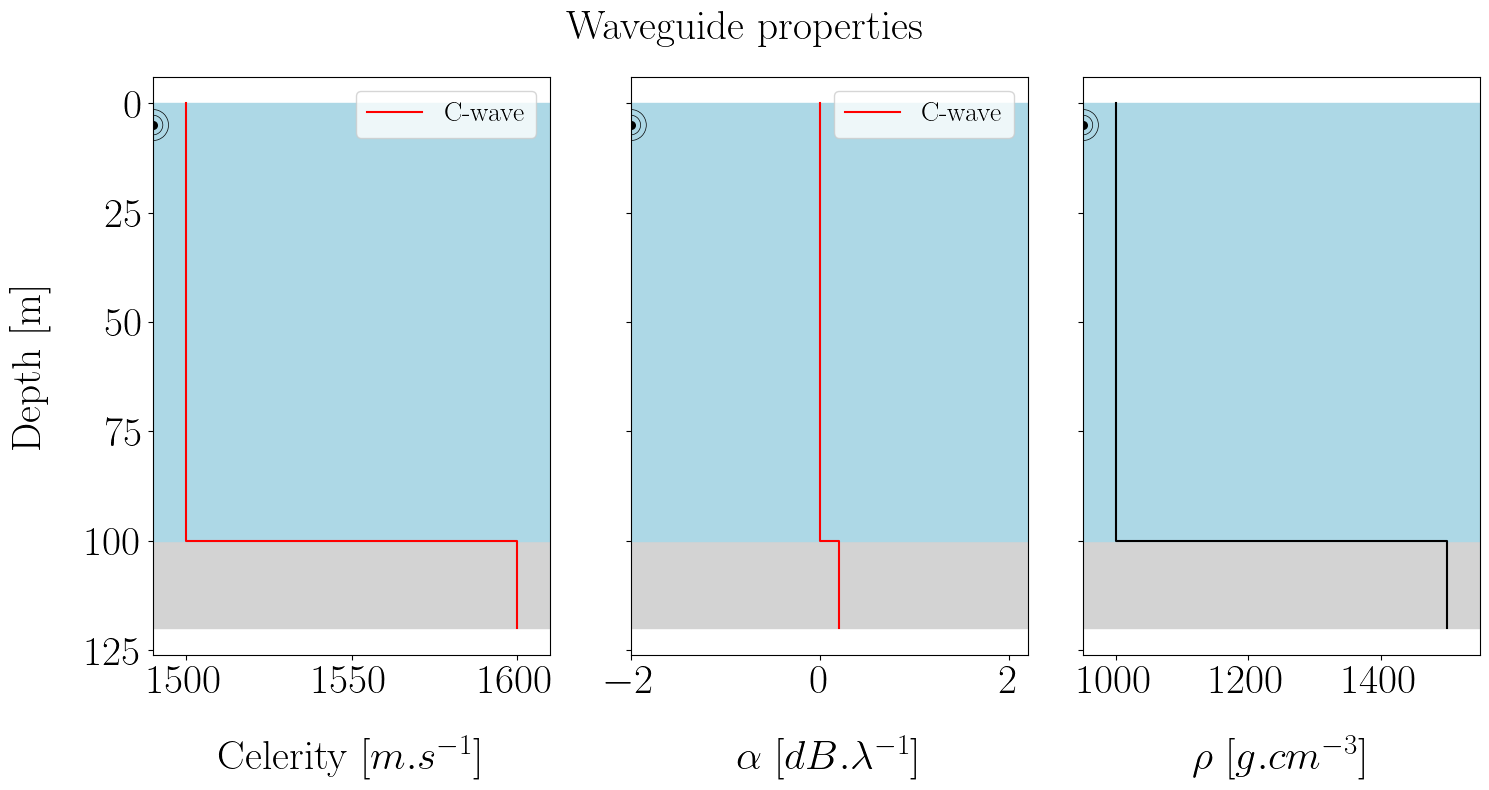

In [10]:
fig_env = env.plot_env(plot_src=True, src_depth=z_s)

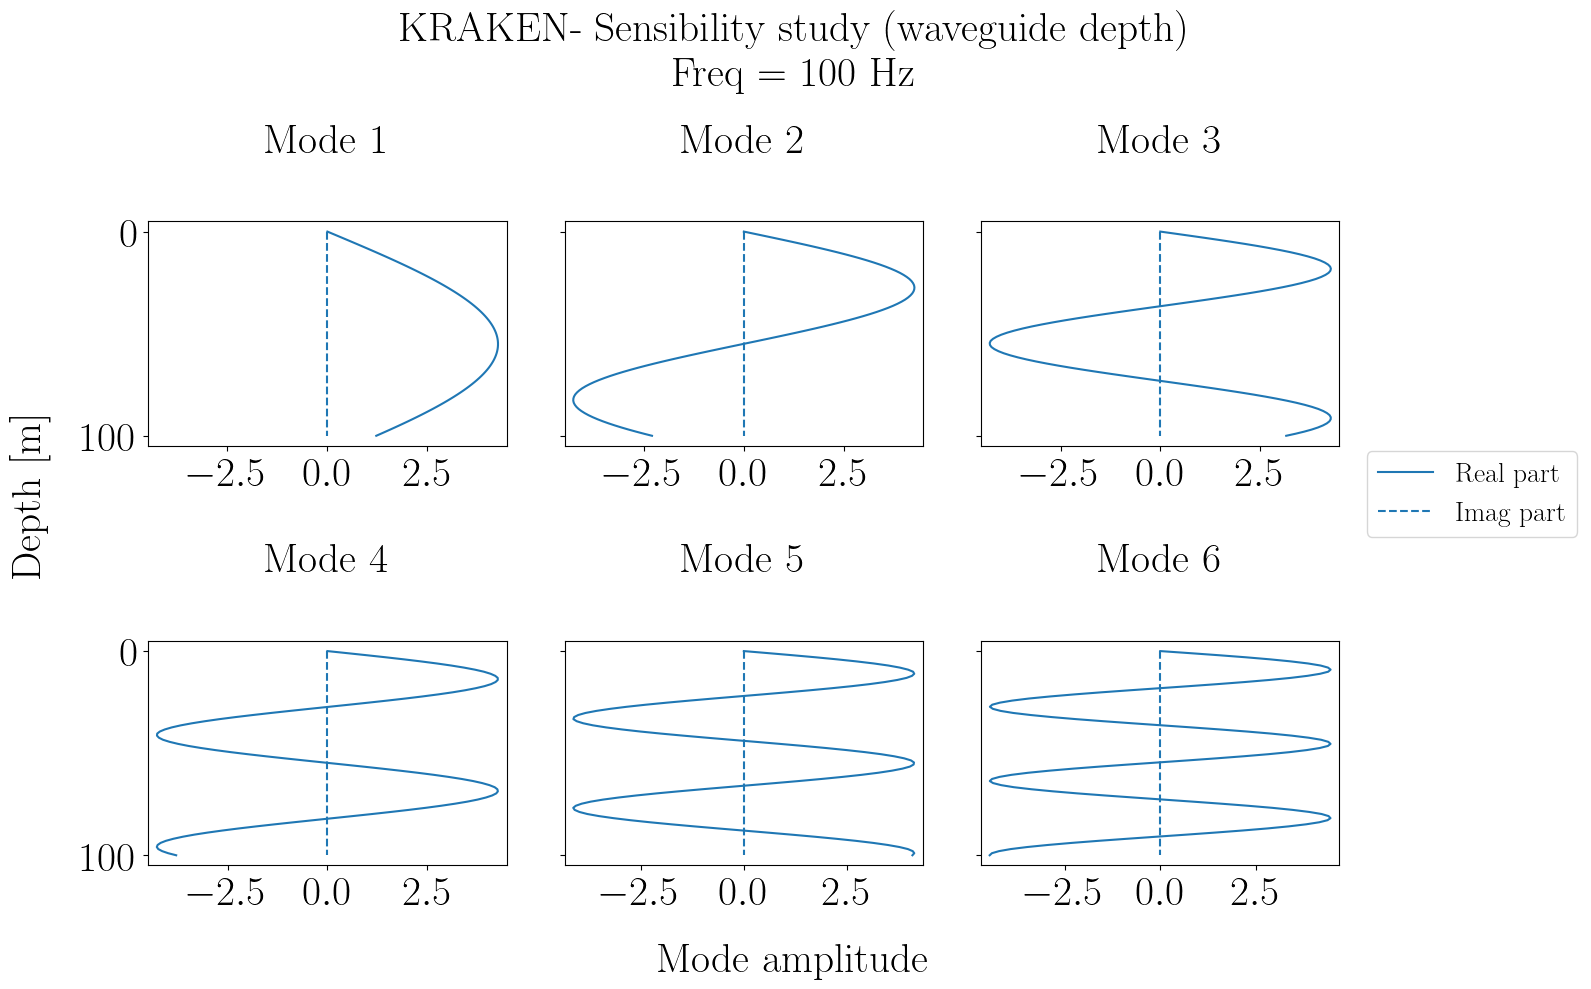

In [11]:
freq_plot = 100
mod_fpath = env.env_fpath.replace(".env", ".mod")
fig1 = pu.plotmode(mod_fpath, freq=freq_plot)

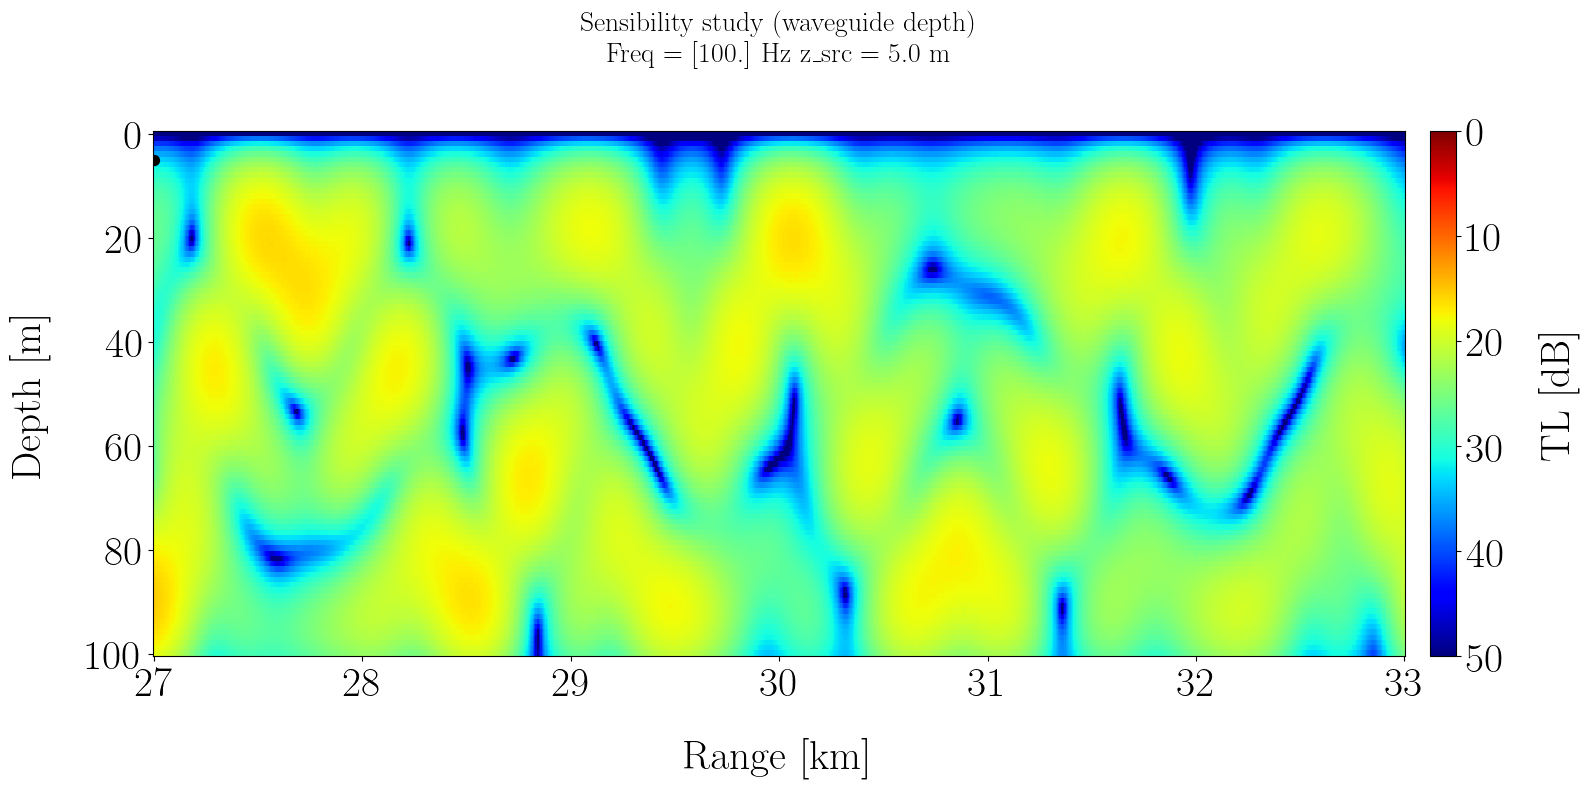

In [12]:
shd_fpath = env.shd_fpath
fig2 = pu.plotshd(shd_fpath, freq=freq_plot, units="km")

C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\plot_utils.py:759: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


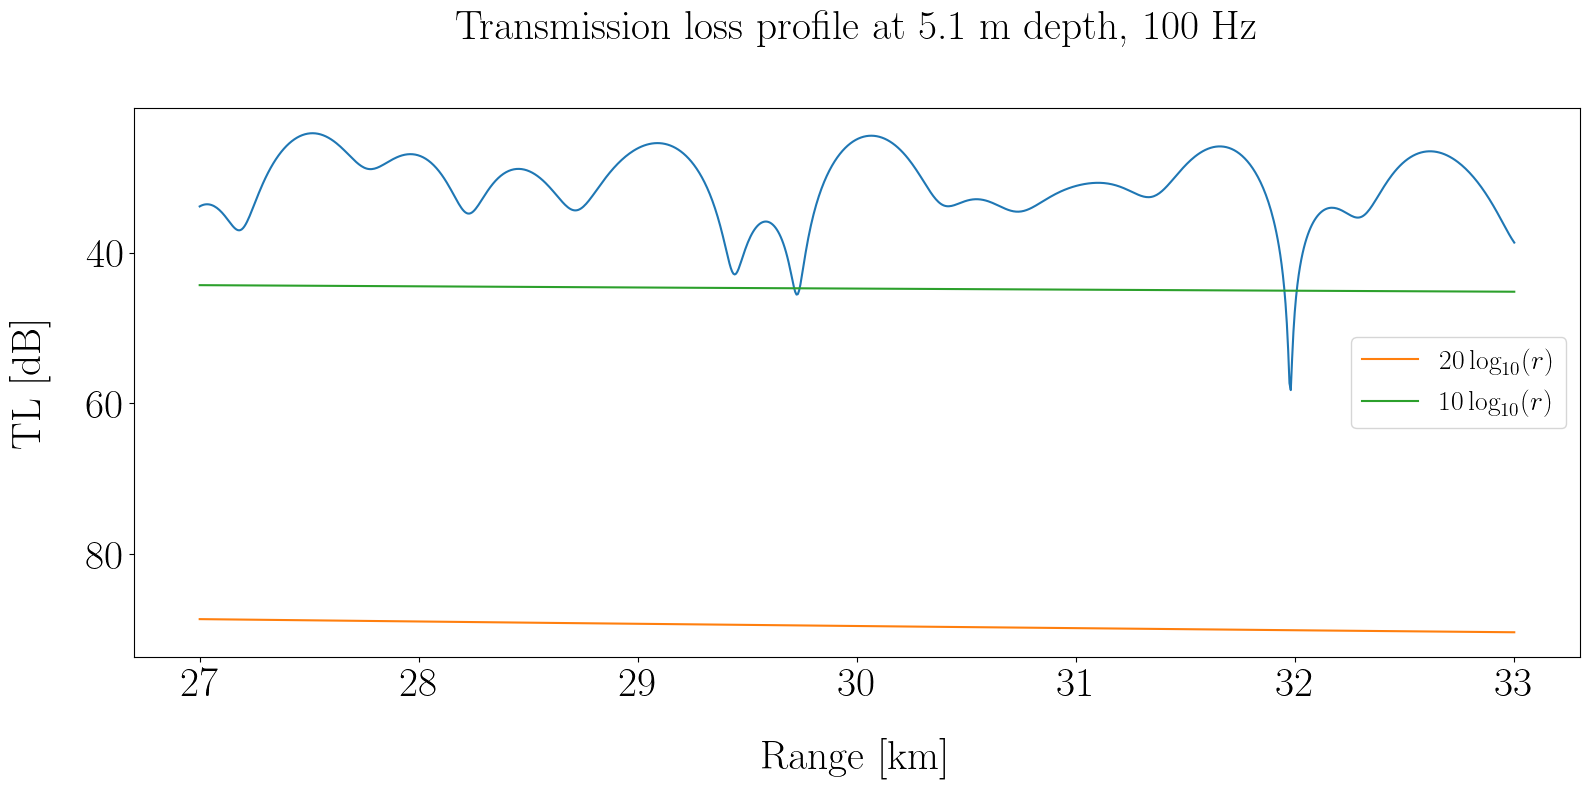

In [13]:
fig3 = pu.plot_tl_profile(
    shd_fpath,
    freq=freq_plot,
    rcv_depth=z_s,
    units="km",
    show_spherical_loss=True,
    show_cylindrical_loss=True,
)

C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\plot_utils.py:797: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


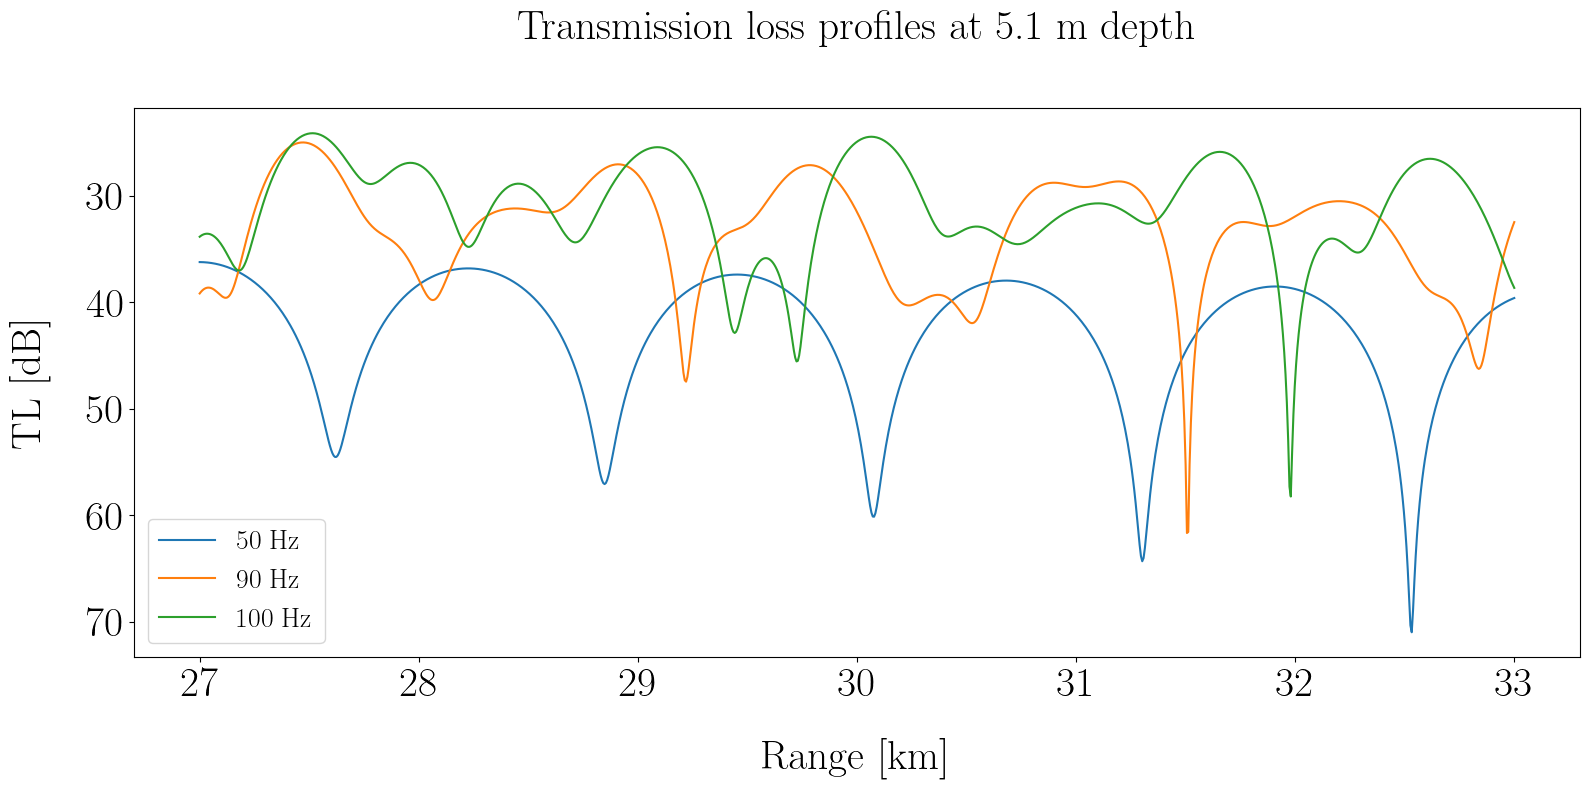

In [14]:
freqs_plot = [50, 90, 100]
fig4 = pu.plot_tl_profile_multi_freq(
    shd_fpath, freqs=freqs_plot, rcv_depth=z_s, units="km"
)

# Plage de valeurs

In [19]:
# npt = int(1e3)
npt = 2

# Depth
d_min = 30
d_max = 5000
d_test = np.linspace(d_min, d_max, npt)
# d_test = np.linspace(50, 150, 20)
# d_test = [2000]

In [16]:
all_arg_dict = env_param.copy()
all_arg_dict.update(sig_param)
all_arg_dict.update(src_rcv_param)
# Remove fmax and fs that are not usefull
all_arg_dict.pop("fs")
all_arg_dict.pop("fmax")

# print(all_arg_dict)

test_arg_name = "depth"
test_arg_values = d_test

width_L1, width_L2, width_theta = run_sensibility_study(
    test_arg_name, test_arg_values, all_arg_dict
)

Progress: █████............................................................................................... 5%Running Kraken  (parallel = False)...
Broadband range independent kraken simulation completed.
KRAKEN/FIELD run completed.
Progress: ██████████.......................................................................................... 10%Running Kraken  (parallel = False)...
Broadband range independent kraken simulation completed.
KRAKEN/FIELD run completed.
Progress: ███████████████..................................................................................... 15%Running Kraken  (parallel = False)...
Broadband range independent kraken simulation completed.
KRAKEN/FIELD run completed.
Progress: ████████████████████................................................................................ 20%Running Kraken  (parallel = False)...
Broadband range independent kraken simulation completed.
KRAKEN/FIELD run completed.
Progress: █████████████████████████..................

Text(0, 0.5, 'Largeur du lobe principal [m]')

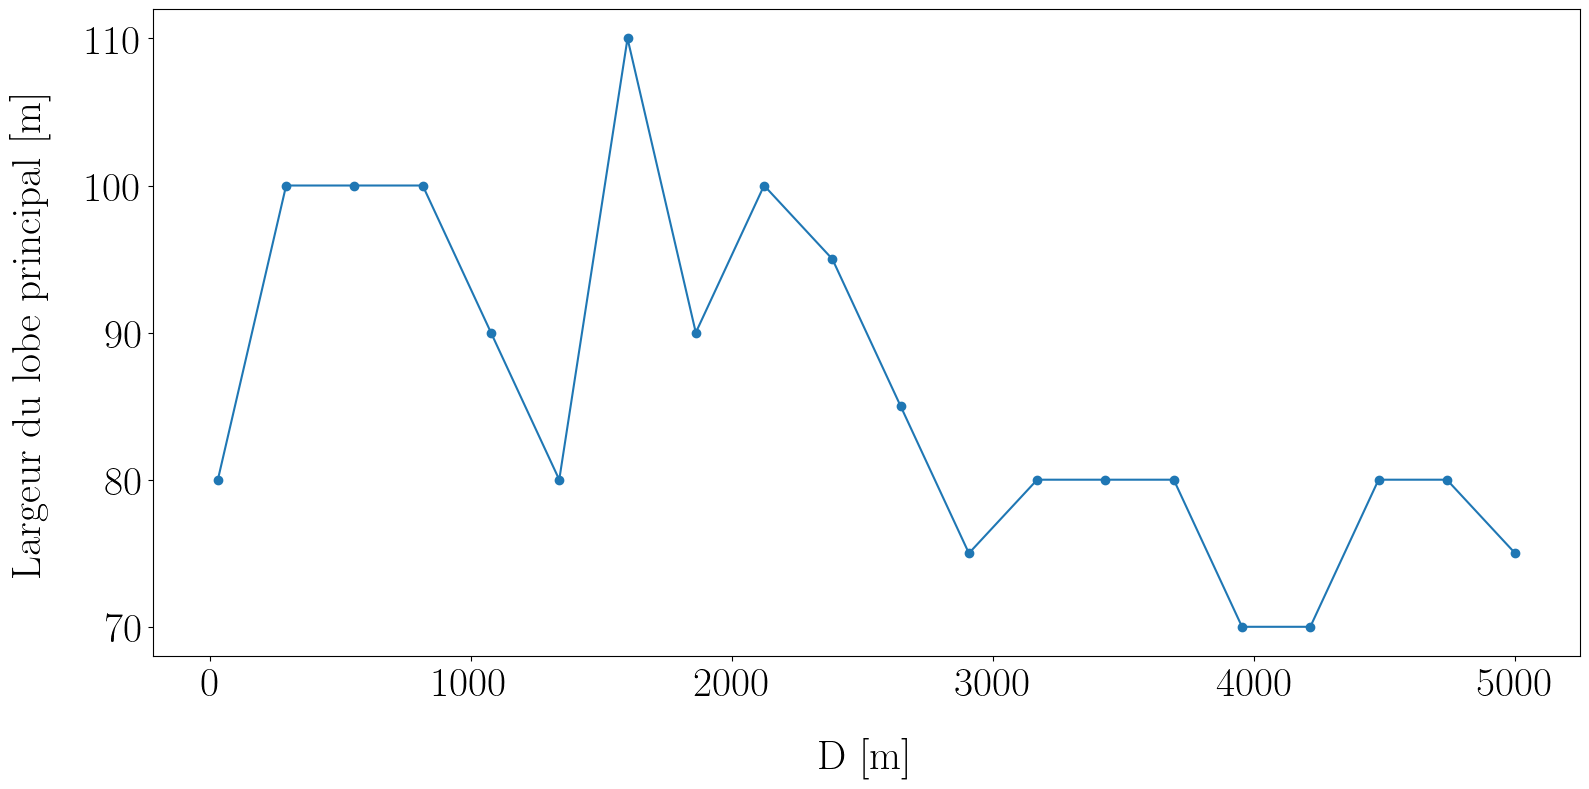

In [18]:
plt.figure()
plt.plot(d_test, width_L1, marker="o")
plt.xlabel("D [m]")
plt.ylabel("Largeur du lobe principal [m]")